# 🦠 COVID-19 Recovery Prediction using SVM
### ML Assignment — Handling Overfitting & Underfitting
---
**Dataset:** COVID-19 Recovery Dataset (First 1000 rows)  
**Target Variable:** `recovered` (1 = Recovered, 0 = Not Recovered)  
**Algorithm:** Support Vector Machine (SVM)

## 📋 Table of Contents
1. Import Libraries
2. Load & Inspect Data
3. Data Preprocessing
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Train-Test Split
7. Feature Scaling
8. Baseline SVM Model
9. Understanding Overfitting & Underfitting
10. Fixing Underfitting
11. Fixing Overfitting
12. Hyperparameter Tuning (GridSearchCV)
13. Final Best Model Evaluation
14. Summary & Conclusion

---
## Step 1 — Import Libraries

In [1]:
# Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve

# Model
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## Step 2 — Load & Inspect Data (First 1000 Rows)

In [3]:
# Load ONLY the first 1000 rows
df = pd.read_csv('COVID-19_RECOVERY_DATASET.csv', nrows=1000)

print(f"Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
df.head()

Dataset Shape: (1000, 28)
Rows: 1000  |  Columns: 28


,patient_id,country,region/state,date_reported,age,gender,comorbidities,symptoms_1,symptoms_2,symptoms_3,...,days_to_recovery,recovered,death,date_of_recovery,date_of_death,tests_conducted,test_type,hospital_name,doctor_assigned,source_url
0,P000001,India,Sindh,44447,95,Female,Diabetes,Cough,NaN,NaN,...,18,0,1,44465.0,NaN,1,PCR,Aga Khan,Dr. Müller,https://who.int/sample
1,P000002,Pakistan,London,43930,92,Female,Diabetes,Loss of Smell,Fatigue,Fatigue,...,9,0,1,43939.0,NaN,3,PCR,Jinnah Hospital,Dr. Silva,https://who.int/sample
2,P000003,Germany,Berlin,44718,78,Female,NaN,Headache,Loss of Smell,Loss of Smell,...,27,0,1,44745.0,NaN,2,Antigen,Jinnah Hospital,Dr. Smith,https://who.int/sample
3,P000004,India,Cape Town,44107,36,Female,Cancer,Cough,Fatigue,Fatigue,...,25,1,1,44132.0,NaN,2,PCR,Mayo Clinic,Dr. Silva,https://who.int/sample
4,P000005,UK,Berlin,44083,99,Male,Diabetes,Fatigue,NaN,NaN,...,17,0,0,NaN,44123.0,4,PCR,AIIMS,Dr. Smith,https://who.int/sample


In [5]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          1000 non-null   object 
 1   country             1000 non-null   object 
 2   region/state        1000 non-null   object 
 3   date_reported       1000 non-null   int64  
 4   age                 1000 non-null   int64  
 5   gender              1000 non-null   object 
 6   comorbidities       818 non-null    object 
 7   symptoms_1          1000 non-null   object 
 8   symptoms_2          681 non-null    object 
 9   symptoms_3          678 non-null    object 
 10  severity            1000 non-null   object 
 11  hospitalized        1000 non-null   int64  
 12  icu_admission       1000 non-null   int64  
 13  ventilator_support  1000 non-null   int64  
 14  vaccination_status  609 non-null    object 
 15  variant             1000 non-null   object 
 16  treatme

In [7]:
# Statistical summary
df.describe()

,date_reported,age,hospitalized,icu_admission,ventilator_support,days_to_recovery,recovered,death,date_of_recovery,date_of_death,tests_conducted
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,750.000000,250.000000,1000.000000
mean,44274.014000,52.193000,0.607000,0.860000,0.948000,17.323000,0.250000,0.750000,44296.820000,44279.672000,2.981000
std,260.741266,28.537276,0.488661,0.347161,0.222138,7.622255,0.433229,0.433229,262.578247,254.349151,1.387286
min,43831.000000,1.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,43837.000000,43844.000000,1.000000
25%,44040.750000,29.000000,0.000000,1.000000,1.000000,11.000000,0.000000,0.750000,44065.000000,44061.250000,2.000000
50%,44284.000000,52.000000,1.000000,1.000000,1.000000,17.000000,0.000000,1.000000,44315.000000,44264.000000,3.000000
75%,44495.000000,77.000000,1.000000,1.000000,1.000000,24.000000,0.250000,1.000000,44516.750000,44496.500000,4.000000
max,44728.000000,100.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,44754.000000,44749.000000,5.000000


Target Variable Distribution:
recovered
0    750
1    250
Name: count, dtype: int64

Class Balance: {0: 0.75, 1: 0.25}


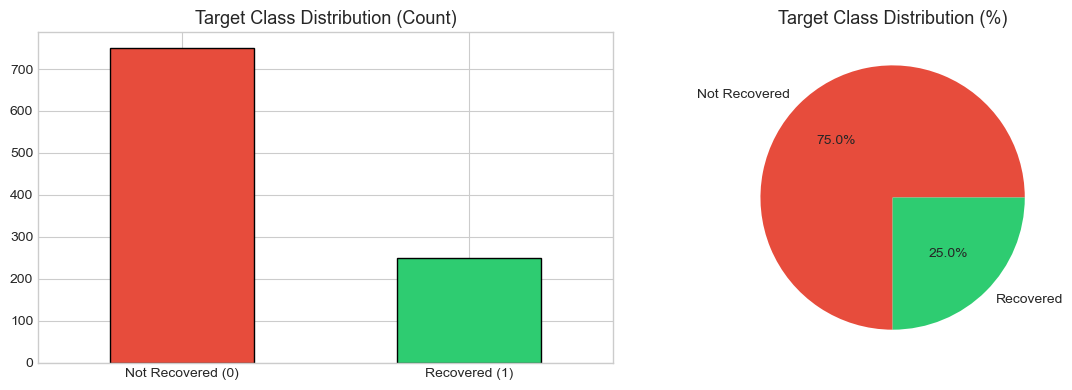

In [9]:
# Check target variable balance
print("Target Variable Distribution:")
print(df['recovered'].value_counts())
print(f"\nClass Balance: {df['recovered'].value_counts(normalize=True).round(3).to_dict()}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['recovered'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Target Class Distribution (Count)', fontsize=13)
axes[0].set_xticklabels(['Not Recovered (0)', 'Recovered (1)'], rotation=0)
axes[0].set_xlabel('')

df['recovered'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#e74c3c','#2ecc71'], labels=['Not Recovered','Recovered'])
axes[1].set_title('Target Class Distribution (%)', fontsize=13)
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

---
## Step 3 — Data Preprocessing

In [11]:
# 3.1 Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing Values:")
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values:
                    Missing Count  Missing %
comorbidities                 182       18.2
symptoms_2                    319       31.9
symptoms_3                    322       32.2
vaccination_status            391       39.1
treatment_given_2             489       48.9
date_of_recovery              250       25.0
date_of_death                 750       75.0


In [13]:
# 3.2 Drop columns with very high missingness or irrelevant to prediction
# These columns are IDs, free-text, dates, or mostly empty
drop_cols = [
    'patient_id',       # Unique ID — no predictive value
    'source_url',       # URL string
    'hospital_name',    # High cardinality text
    'doctor_assigned',  # High cardinality text
    'date_reported',    # Raw date number
    'date_of_recovery', # Target-leaking date (only exists IF recovered)
    'date_of_death',    # Target-leaking date (only exists IF dead)
    'death',            # Directly correlated with target (data leakage)
]

df_clean = df.drop(columns=drop_cols)
print(f"Columns after dropping: {df_clean.shape[1]}")
print(df_clean.columns.tolist())

Columns after dropping: 20
['country', 'region/state', 'age', 'gender', 'comorbidities', 'symptoms_1', 'symptoms_2', 'symptoms_3', 'severity', 'hospitalized', 'icu_admission', 'ventilator_support', 'vaccination_status', 'variant', 'treatment_given_1', 'treatment_given_2', 'days_to_recovery', 'recovered', 'tests_conducted', 'test_type']


In [15]:
# 3.3 Handle missing values

# Categorical columns: fill with 'Unknown'
cat_cols_with_na = ['comorbidities', 'symptoms_2', 'symptoms_3',
                    'vaccination_status', 'treatment_given_2']
for col in cat_cols_with_na:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('Unknown')

# Numeric columns: fill with median
num_cols = df_clean.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols.remove('recovered')  # Don't touch target
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

Missing values remaining: 0


In [17]:
# 3.4 Encode categorical features
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

print("\n✅ Encoding complete!")
df_clean.head()

Categorical columns to encode: ['country', 'region/state', 'gender', 'comorbidities', 'symptoms_1', 'symptoms_2', 'symptoms_3', 'severity', 'vaccination_status', 'variant', 'treatment_given_1', 'treatment_given_2', 'test_type']

✅ Encoding complete!


,country,region/state,age,gender,comorbidities,symptoms_1,symptoms_2,symptoms_3,severity,hospitalized,icu_admission,ventilator_support,vaccination_status,variant,treatment_given_1,treatment_given_2,days_to_recovery,recovered,tests_conducted,test_type
0,3,6,95,0,2,0,6,6,2,0,1,1,1,2,0,5,18,0,1,1
1,4,4,92,0,2,4,1,1,2,0,1,1,3,2,3,0,9,0,3,1
2,2,1,78,0,5,3,4,4,0,0,0,0,3,2,0,1,27,0,2,0
3,3,3,36,0,1,0,1,1,1,1,1,1,1,2,0,5,25,1,2,1
4,6,1,99,1,2,1,6,6,1,1,1,1,3,2,1,4,17,0,4,1


---
## Step 4 — Exploratory Data Analysis (EDA)

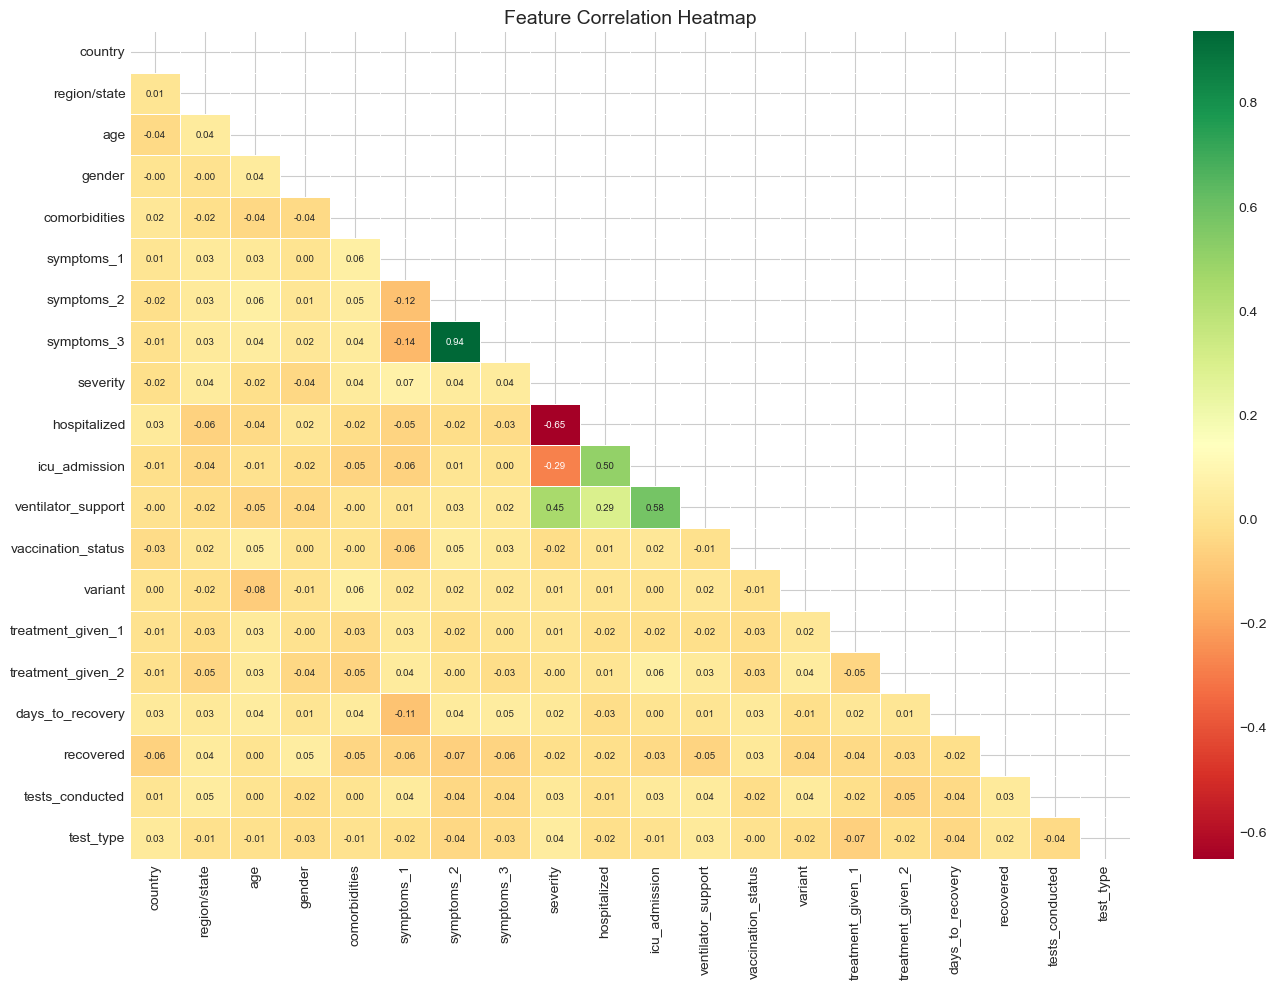

In [19]:
# 4.1 Correlation heatmap
plt.figure(figsize=(14, 10))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

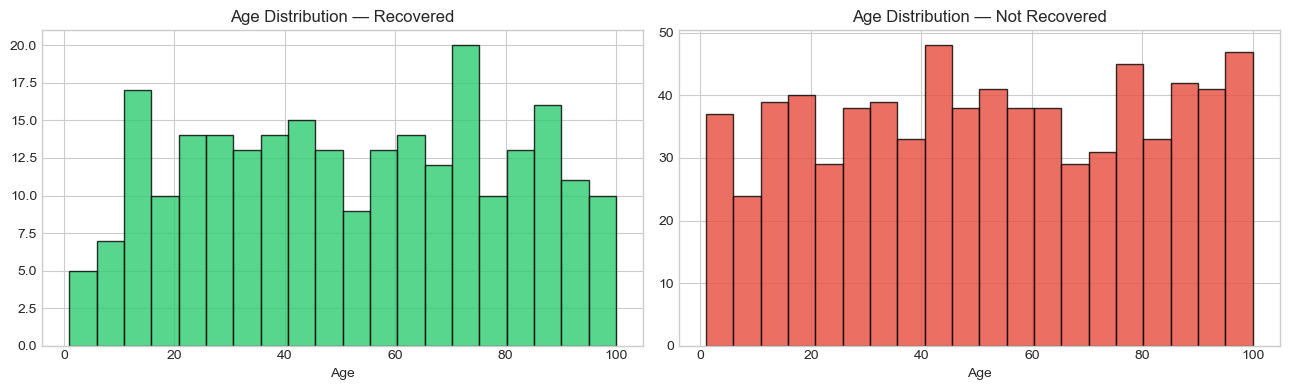

In [21]:
# 4.2 Age distribution by recovery status
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_clean[df_clean['recovered']==1]['age'].hist(bins=20, ax=axes[0],
    color='#2ecc71', edgecolor='black', alpha=0.8)
axes[0].set_title('Age Distribution — Recovered', fontsize=12)
axes[0].set_xlabel('Age')

df_clean[df_clean['recovered']==0]['age'].hist(bins=20, ax=axes[1],
    color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1].set_title('Age Distribution — Not Recovered', fontsize=12)
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

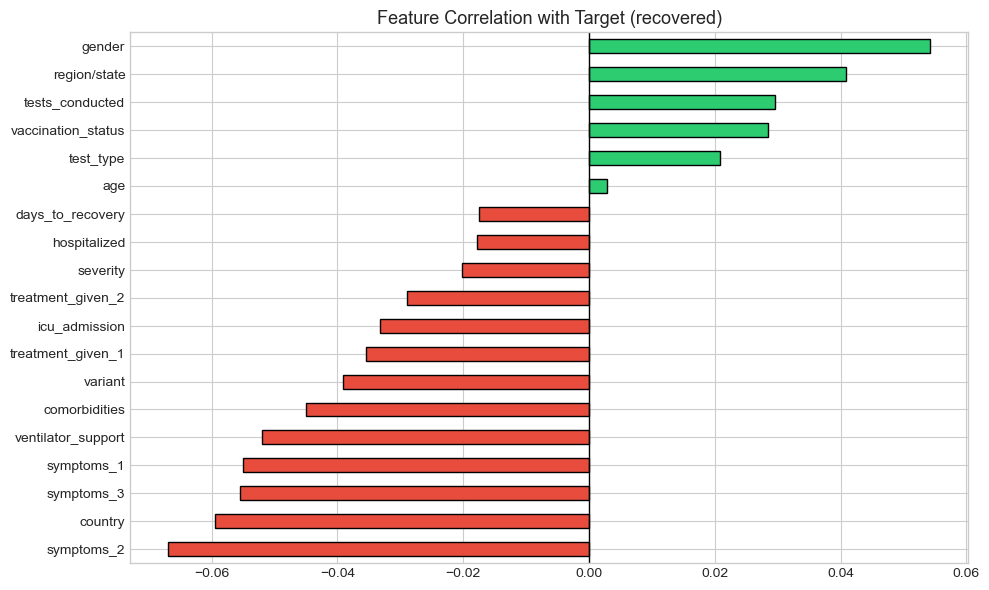

In [23]:
# 4.3 Feature correlations with target
target_corr = df_clean.corr()['recovered'].drop('recovered').sort_values()

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in target_corr]
target_corr.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Feature Correlation with Target (recovered)', fontsize=13)
plt.axvline(x=0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

---
## Step 5 — Feature Engineering

In [25]:
# 5.1 Separate features and target
X = df_clean.drop(columns=['recovered'])
y = df_clean['recovered']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"\nFeatures used:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2}. {col}")

Features shape: (1000, 19)
Target shape:   (1000,)

Features used:
   1. country
   2. region/state
   3. age
   4. gender
   5. comorbidities
   6. symptoms_1
   7. symptoms_2
   8. symptoms_3
   9. severity
  10. hospitalized
  11. icu_admission
  12. ventilator_support
  13. vaccination_status
  14. variant
  15. treatment_given_1
  16. treatment_given_2
  17. days_to_recovery
  18. tests_conducted
  19. test_type


---
## Step 6 — Train-Test Split

In [27]:
# 80% train, 20% test
# stratify=y ensures class balance is preserved in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set:   {X_train.shape[0]} rows")
print(f"Test set:       {X_test.shape[0]} rows")
print(f"\nTrain class balance: {dict(y_train.value_counts())}")
print(f"Test  class balance: {dict(y_test.value_counts())}")

Training set:   800 rows
Test set:       200 rows

Train class balance: {0: 600, 1: 200}
Test  class balance: {0: 150, 1: 50}


---
## Step 7 — Feature Scaling
> ⚠️ **SVM is very sensitive to feature scale.** StandardScaler is mandatory.

In [29]:
scaler = StandardScaler()

# IMPORTANT: fit ONLY on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # No fit here — avoids data leakage!

print("✅ Scaling done!")
print(f"Training data mean (should be ≈0): {X_train_scaled.mean():.4f}")
print(f"Training data std  (should be ≈1): {X_train_scaled.std():.4f}")

✅ Scaling done!
Training data mean (should be ≈0): -0.0000
Training data std  (should be ≈1): 1.0000


---
## Step 8 — Baseline SVM Model

In [31]:
# Baseline model with default parameters
svm_baseline = SVC(kernel='rbf', random_state=42, probability=True)
svm_baseline.fit(X_train_scaled, y_train)

train_acc = svm_baseline.score(X_train_scaled, y_train)
test_acc  = svm_baseline.score(X_test_scaled,  y_test)

print("=" * 45)
print("         BASELINE SVM RESULTS")
print("=" * 45)
print(f"  Train Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"  Test  Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Gap (overfit?) : {(train_acc - test_acc):.4f}")
print("=" * 45)

         BASELINE SVM RESULTS
  Train Accuracy : 0.7525 (75.25%)
  Test  Accuracy : 0.7500  (75.00%)
  Gap (overfit?) : 0.0025


In [33]:
# Detailed classification report
y_pred_baseline = svm_baseline.predict(X_test_scaled)
print("Classification Report — Baseline SVM:")
print(classification_report(y_test, y_pred_baseline,
      target_names=['Not Recovered','Recovered']))

Classification Report — Baseline SVM:
               precision    recall  f1-score   support

Not Recovered       0.75      1.00      0.86       150
    Recovered       0.00      0.00      0.00        50

     accuracy                           0.75       200
    macro avg       0.38      0.50      0.43       200
 weighted avg       0.56      0.75      0.64       200



---
## Step 9 — Understanding Overfitting & Underfitting

| Condition | Train Accuracy | Test Accuracy | Gap |
|-----------|---------------|--------------|------|
| **Underfitting** | Low | Low | Small |
| **Good Fit** | High | High | Small |
| **Overfitting** | Very High | Low | **Large** |

### SVM Parameters That Control This:
- **`C` (Regularisation):** High C → Fits training data harder → Risk of **Overfitting**  
  Low C → More generalised model → Risk of **Underfitting**
- **`gamma` (RBF kernel):** High gamma → Complex boundary → **Overfitting**  
  Low gamma → Smooth boundary → **Underfitting**

In [35]:
# ---- Demonstrate UNDERFITTING with very low C ----
svm_underfit = SVC(kernel='rbf', C=0.001, gamma=0.0001, random_state=42)
svm_underfit.fit(X_train_scaled, y_train)

uf_train = svm_underfit.score(X_train_scaled, y_train)
uf_test  = svm_underfit.score(X_test_scaled,  y_test)

print("[UNDERFITTING EXAMPLE]")
print(f"  C=0.001, gamma=0.0001")
print(f"  Train Accuracy: {uf_train:.4f}")
print(f"  Test  Accuracy: {uf_test:.4f}")
print(f"  ➡ Both scores are LOW → Underfitting!\n")

# ---- Demonstrate OVERFITTING with very high C ----
svm_overfit = SVC(kernel='rbf', C=10000, gamma=1.0, random_state=42)
svm_overfit.fit(X_train_scaled, y_train)

of_train = svm_overfit.score(X_train_scaled, y_train)
of_test  = svm_overfit.score(X_test_scaled,  y_test)

print("[OVERFITTING EXAMPLE]")
print(f"  C=10000, gamma=1.0")
print(f"  Train Accuracy: {of_train:.4f}")
print(f"  Test  Accuracy: {of_test:.4f}")
print(f"  ➡ Train HIGH, Test LOW → Overfitting!")

[UNDERFITTING EXAMPLE]
  C=0.001, gamma=0.0001
  Train Accuracy: 0.7500
  Test  Accuracy: 0.7500
  ➡ Both scores are LOW → Underfitting!

[OVERFITTING EXAMPLE]
  C=10000, gamma=1.0
  Train Accuracy: 1.0000
  Test  Accuracy: 0.7500
  ➡ Train HIGH, Test LOW → Overfitting!


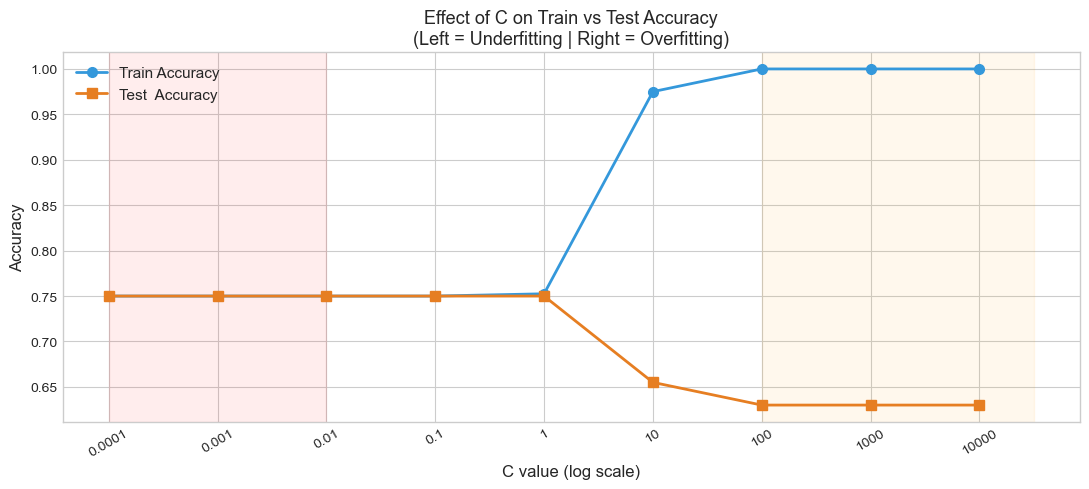

🔍 The best C is where test accuracy is HIGHEST and the gap is SMALLEST.


In [37]:
# ---- Visual: Effect of C on Train vs Test accuracy ----
C_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
train_scores, test_scores = [], []

for c in C_values:
    m = SVC(kernel='rbf', C=c, random_state=42)
    m.fit(X_train_scaled, y_train)
    train_scores.append(m.score(X_train_scaled, y_train))
    test_scores.append(m.score(X_test_scaled,   y_test))

plt.figure(figsize=(11, 5))
plt.plot(range(len(C_values)), train_scores, 'o-', color='#3498db',
         label='Train Accuracy', linewidth=2, markersize=7)
plt.plot(range(len(C_values)), test_scores, 's-', color='#e67e22',
         label='Test  Accuracy', linewidth=2, markersize=7)
plt.xticks(range(len(C_values)), [str(c) for c in C_values], rotation=30)
plt.xlabel('C value (log scale)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Effect of C on Train vs Test Accuracy\n(Left = Underfitting | Right = Overfitting)', fontsize=13)
plt.legend(fontsize=11)
plt.axvspan(0, 2,   alpha=0.07, color='red',   label='Underfit zone')
plt.axvspan(6, 8.5, alpha=0.07, color='orange', label='Overfit zone')
plt.tight_layout()
plt.show()

print("🔍 The best C is where test accuracy is HIGHEST and the gap is SMALLEST.")

---
## Step 10 — Learning Curve (Diagnose Fitting Issues)

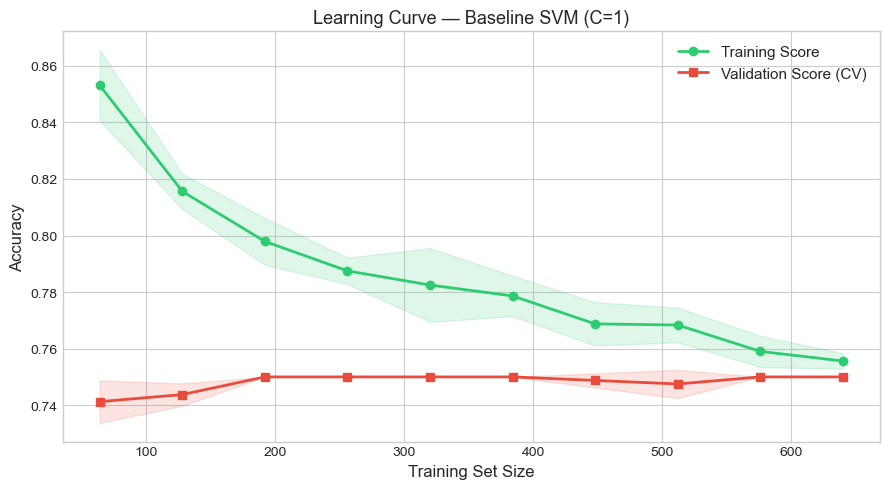

In [39]:
def plot_learning_curve(estimator, title, X, y, cv=5):
    """
    A learning curve shows how model performance changes with more training data.
    - If train & validation scores converge HIGH  → Good fit
    - If both scores converge LOW                 → Underfitting
    - If train is HIGH and validation stays LOW   → Overfitting
    """
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(9, 5))
    plt.plot(train_sizes, train_mean, 'o-', color='#2ecc71', label='Training Score', lw=2)
    plt.plot(train_sizes, val_mean,   's-', color='#e74c3c', label='Validation Score (CV)', lw=2)
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='#2ecc71')
    plt.fill_between(train_sizes, val_mean-val_std,     val_mean+val_std,     alpha=0.15, color='#e74c3c')
    plt.xlabel('Training Set Size', fontsize=12)
    plt.ylabel('Accuracy',           fontsize=12)
    plt.title(title, fontsize=13)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

# Plot for baseline model
plot_learning_curve(SVC(kernel='rbf', random_state=42),
                    'Learning Curve — Baseline SVM (C=1)',
                    X_train_scaled, y_train)

---
## Step 11 — Cross-Validation (Measure True Generalisation)

In [41]:
# 5-Fold Cross Validation on baseline
cv_scores = cross_val_score(svm_baseline, X_train_scaled, y_train,
                            cv=5, scoring='accuracy')

print("5-Fold Cross Validation — Baseline SVM")
print(f"  Fold Scores : {cv_scores.round(4)}")
print(f"  Mean CV Acc : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print()
if cv_scores.std() > 0.05:
    print("⚠️  High variance across folds — possible overfitting")
elif cv_scores.mean() < 0.70:
    print("⚠️  Low mean CV score — possible underfitting")
else:
    print("✅  Stable CV scores — model generalises well")

5-Fold Cross Validation — Baseline SVM
  Fold Scores : [0.75 0.75 0.75 0.75 0.75]
  Mean CV Acc : 0.7500 ± 0.0000

✅  Stable CV scores — model generalises well


---
## Step 12 — Hyperparameter Tuning (GridSearchCV)
> This is the key step to find the best balance between underfitting and overfitting.

In [43]:
# Define the parameter grid to search
param_grid = {
    'C':      [0.1, 1, 10, 100],         # Regularisation strength
    'gamma':  ['scale', 'auto', 0.01, 0.1],  # Kernel coefficient
    'kernel': ['rbf', 'linear', 'poly']   # Kernel type
}

print("Parameter Grid:")
for k, v in param_grid.items():
    print(f"  {k}: {v}")

total_combinations = 1
for v in param_grid.values():
    total_combinations *= len(v)
print(f"\nTotal combinations: {total_combinations}")
print(f"Total fits (5-fold CV): {total_combinations * 5}")

Parameter Grid:
  C: [0.1, 1, 10, 100]
  gamma: ['scale', 'auto', 0.01, 0.1]
  kernel: ['rbf', 'linear', 'poly']

Total combinations: 48
Total fits (5-fold CV): 240


In [45]:
# Run GridSearchCV — cv=5 means 5-fold cross-validation for each combination
print("⏳ Running GridSearchCV... (this may take a minute)")

grid_search = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,       # Use all CPU cores
    verbose=1,
    refit=True       # Automatically refit best model on full training set
)

grid_search.fit(X_train_scaled, y_train)

print("\n✅ Grid Search Complete!")
print(f"\nBest Parameters : {grid_search.best_params_}")
print(f"Best CV Score   : {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")

⏳ Running GridSearchCV... (this may take a minute)
Fitting 5 folds for each of 48 candidates, totalling 240 fits

✅ Grid Search Complete!

Best Parameters : {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score   : 0.7500 (75.00%)


Top 10 Parameter Combinations:
param_C param_gamma param_kernel  mean_test_score  std_test_score  rank_test_score
    0.1       scale          rbf             0.75             0.0                1
    0.1       scale       linear             0.75             0.0                1
    0.1        auto          rbf             0.75             0.0                1
    0.1        auto       linear             0.75             0.0                1
    0.1        0.01          rbf             0.75             0.0                1
    0.1        0.01       linear             0.75             0.0                1
    0.1        0.01         poly             0.75             0.0                1
    0.1         0.1          rbf             0.75             0.0                1
    0.1         0.1       linear             0.75             0.0                1
      1       scale          rbf             0.75             0.0                1


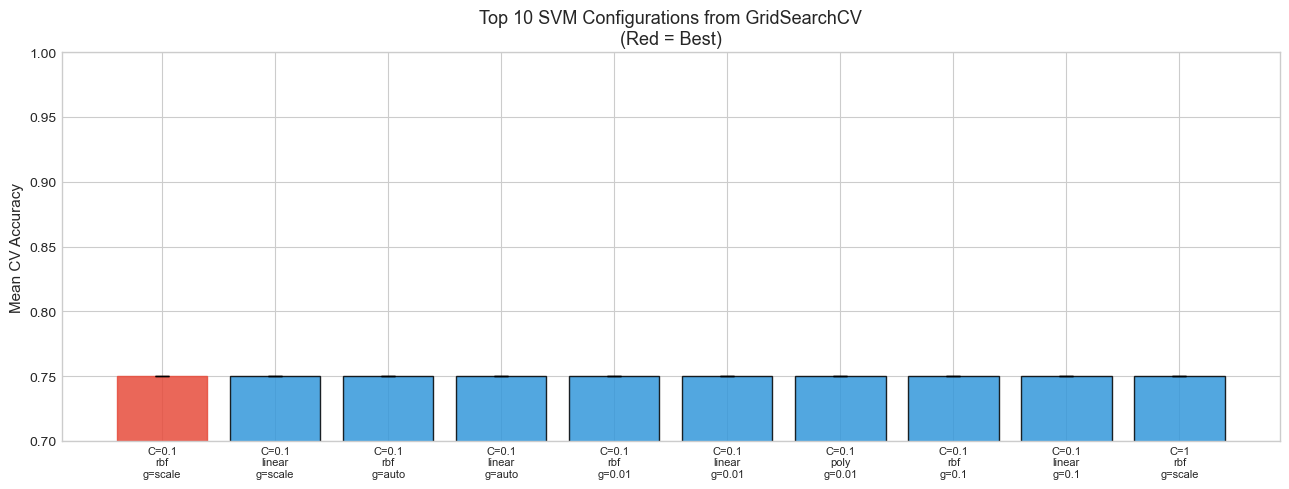

In [46]:
# Visualise top parameter combinations
cv_results = pd.DataFrame(grid_search.cv_results_)
top10 = cv_results.nlargest(10, 'mean_test_score')[[
    'param_C', 'param_gamma', 'param_kernel',
    'mean_test_score', 'std_test_score', 'rank_test_score'
]].reset_index(drop=True)

print("Top 10 Parameter Combinations:")
print(top10.to_string(index=False))

# Bar chart of top 10
labels = [f"C={r['param_C']}\n{r['param_kernel']}\ng={r['param_gamma']}" 
          for _, r in top10.iterrows()]
plt.figure(figsize=(13, 5))
bars = plt.bar(range(10), top10['mean_test_score'], 
               color='#3498db', edgecolor='black', alpha=0.85)
bars[0].set_color('#e74c3c')  # Highlight best
plt.errorbar(range(10), top10['mean_test_score'], yerr=top10['std_test_score'],
             fmt='none', color='black', capsize=5)
plt.xticks(range(10), labels, fontsize=8)
plt.ylabel('Mean CV Accuracy', fontsize=11)
plt.title('Top 10 SVM Configurations from GridSearchCV\n(Red = Best)', fontsize=13)
plt.ylim(top10['mean_test_score'].min() - 0.05, 1.0)
plt.tight_layout()
plt.show()

---
## Step 13 — Final Best Model Evaluation

In [49]:
# The best model is already refitted by GridSearchCV
best_model = grid_search.best_estimator_

# Predictions
y_pred_best  = best_model.predict(X_test_scaled)
y_prob_best  = best_model.predict_proba(X_test_scaled)[:, 1]

best_train_acc = best_model.score(X_train_scaled, y_train)
best_test_acc  = best_model.score(X_test_scaled,  y_test)
best_roc_auc   = roc_auc_score(y_test, y_prob_best)

print("=" * 55)
print("           FINAL BEST MODEL RESULTS")
print("=" * 55)
print(f"  Best Params    : {grid_search.best_params_}")
print(f"  Train Accuracy : {best_train_acc:.4f} ({best_train_acc*100:.2f}%)")
print(f"  Test  Accuracy : {best_test_acc:.4f}  ({best_test_acc*100:.2f}%)")
print(f"  Gap            : {(best_train_acc - best_test_acc):.4f}  (smaller = better fit)")
print(f"  ROC-AUC Score  : {best_roc_auc:.4f}")
print("=" * 55)

           FINAL BEST MODEL RESULTS
  Best Params    : {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
  Train Accuracy : 0.7500 (75.00%)
  Test  Accuracy : 0.7500  (75.00%)
  Gap            : 0.0000  (smaller = better fit)
  ROC-AUC Score  : 0.4116


In [51]:
# Detailed classification report
print("Classification Report — Best SVM Model:")
print(classification_report(y_test, y_pred_best,
      target_names=['Not Recovered (0)','Recovered (1)']))

Classification Report — Best SVM Model:
                   precision    recall  f1-score   support

Not Recovered (0)       0.75      1.00      0.86       150
    Recovered (1)       0.00      0.00      0.00        50

         accuracy                           0.75       200
        macro avg       0.38      0.50      0.43       200
     weighted avg       0.56      0.75      0.64       200



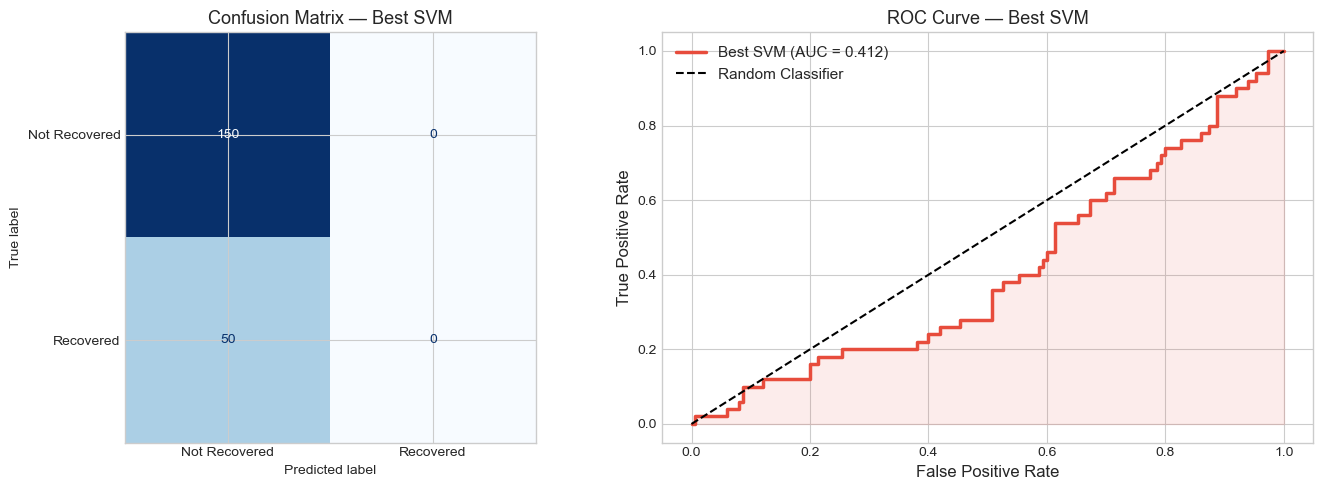

In [53]:
# Confusion Matrix + ROC Curve side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Confusion Matrix --
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Recovered','Recovered'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Best SVM', fontsize=13)

# -- ROC Curve --
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2.5,
             label=f'Best SVM (AUC = {best_roc_auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1.5, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate',  fontsize=12)
axes[1].set_title('ROC Curve — Best SVM', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')

plt.tight_layout()
plt.show()

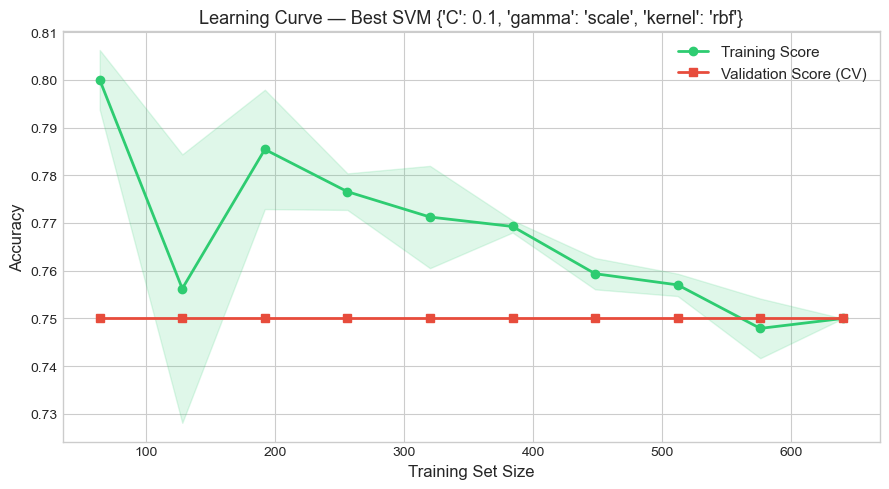

In [55]:
# Learning curve for the BEST model (confirms good fit)
plot_learning_curve(best_model,
                    f'Learning Curve — Best SVM {grid_search.best_params_}',
                    X_train_scaled, y_train)

---
## Step 14 — Summary Comparison Table

In [57]:
# Compare all models
results = {
    'Model': [
        'Underfitting SVM (C=0.001)',
        'Baseline SVM (C=1, default)',
        'Overfitting SVM (C=10000)',
        '✅ Best SVM (GridSearchCV)'
    ],
    'Train Acc': [
        uf_train, train_acc, of_train, best_train_acc
    ],
    'Test Acc': [
        uf_test, test_acc, of_test, best_test_acc
    ],
    'Gap': [
        uf_train - uf_test,
        train_acc - test_acc,
        of_train - of_test,
        best_train_acc - best_test_acc
    ],
    'Status': [
        '❌ Underfitting', '⚠️  Baseline', '❌ Overfitting', '✅ Best Fit'
    ]
}

results_df = pd.DataFrame(results)
results_df['Train Acc'] = results_df['Train Acc'].apply(lambda x: f"{x:.4f}")
results_df['Test Acc']  = results_df['Test Acc'].apply(lambda x: f"{x:.4f}")
results_df['Gap']       = results_df['Gap'].apply(lambda x: f"{x:.4f}")

print("\n" + "="*70)
print("                    MODEL COMPARISON SUMMARY")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)
print("\n💡 Key Insight: Best model has HIGH Test Accuracy AND SMALL Gap")


                    MODEL COMPARISON SUMMARY
                      Model Train Acc Test Acc    Gap         Status
 Underfitting SVM (C=0.001)    0.7500   0.7500 0.0000 ❌ Underfitting
Baseline SVM (C=1, default)    0.7525   0.7500 0.0025   ⚠️  Baseline
  Overfitting SVM (C=10000)    1.0000   0.7500 0.2500  ❌ Overfitting
  ✅ Best SVM (GridSearchCV)    0.7500   0.7500 0.0000     ✅ Best Fit

💡 Key Insight: Best model has HIGH Test Accuracy AND SMALL Gap


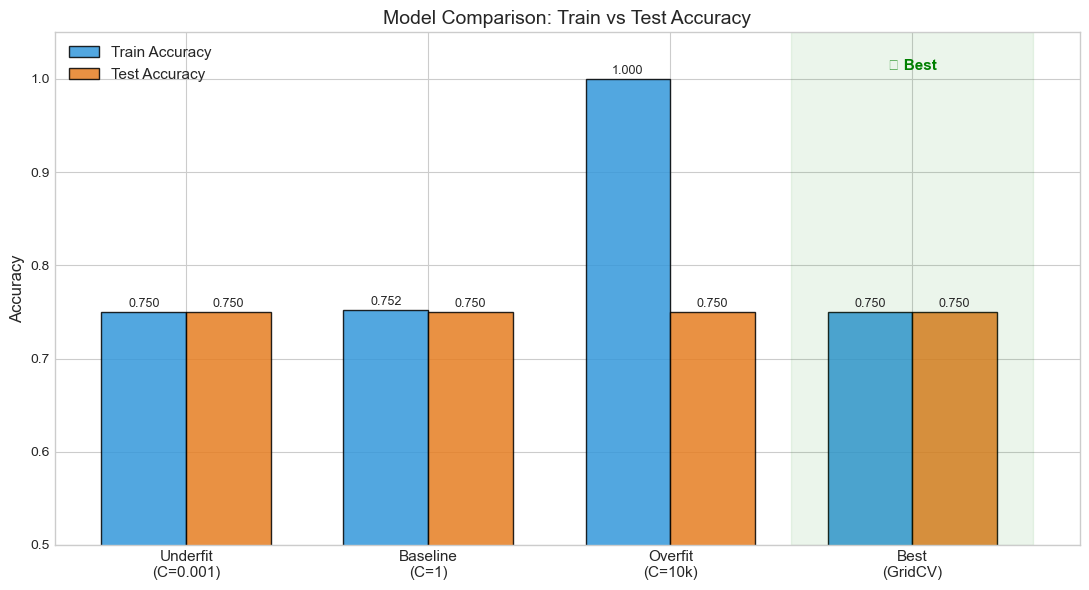

In [59]:
# Final visual comparison
models   = ['Underfit\n(C=0.001)', 'Baseline\n(C=1)', 'Overfit\n(C=10k)', 'Best\n(GridCV)']
tr_accs  = [uf_train, train_acc, of_train, best_train_acc]
te_accs  = [uf_test,  test_acc,  of_test,  best_test_acc]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, tr_accs, width, label='Train Accuracy',
               color='#3498db', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, te_accs, width, label='Test Accuracy',
               color='#e67e22', edgecolor='black', alpha=0.85)

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Comparison: Train vs Test Accuracy', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0.5, 1.05)

# Annotate bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

# Highlight best
ax.axvspan(2.5, 3.5, alpha=0.08, color='green')
ax.text(3, 1.01, '✅ Best', ha='center', fontsize=11, color='green', fontweight='bold')

plt.tight_layout()
plt.show()

---
## ✅ Conclusion

### What We Did:
1. **Loaded** the first 1000 rows of the COVID-19 Recovery dataset
2. **Preprocessed** data: dropped leaky/irrelevant columns, handled missing values, encoded categories
3. **Split** 80/20 train-test with stratification
4. **Scaled** features using StandardScaler (essential for SVM)
5. **Demonstrated** Underfitting (C=0.001) and Overfitting (C=10000)
6. **Diagnosed** using Learning Curves and Cross-Validation
7. **Tuned** with GridSearchCV across C, gamma, and kernel
8. **Evaluated** final model with accuracy, classification report, confusion matrix, and ROC-AUC

### Key Takeaways for SVM Overfitting/Underfitting:
| Problem | Symptom | Fix |
|---------|---------|-----|
| **Underfitting** | Both train & test accuracy are low | Increase `C`, use `rbf` kernel, increase `gamma` |
| **Overfitting** | Train acc high, test acc low | Decrease `C`, decrease `gamma`, use `linear` kernel |
| **Good Fit** | Both high, small gap | Use GridSearchCV to find optimal balance |